ValueError: x and y must be the same size

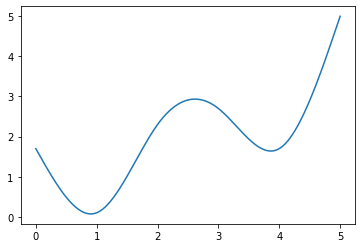

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]                                                          # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])                                                 # Main diagonal
        C[i - 1] = h[i]                                                            # Superdiagonal
        D[i - 1] = 6 * (((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]))             # Right-hand side vector

    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x, y, M, xval):
    for i in range(len(x) - 1):
        if x[i] <= xval <= x[i+1]:
            h = x[i+1] - x[i]
            first = M[i] / (6*h) * ((x[i+1] - xval)**3)
            second = M[i+1] / (6*h) * ((xval - x[i])**3)
            third = ((y[i] / h) - ((M[i] * h / 6))) * (x[i+1] - xval)
            fourth = ((y[i+1] / h) - ((M[i+1] * h / 6))) * (xval - x[i])
            
            S = first + second + third + fourth
            return S

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

A, B, C, D = setup_tridiagonal_matrix(x, y)
D2 = thomas_algorithm(A, B, C, D)

M= np.zeros(len(x))
M[1:-1] = D2

xvals= []
yvals= []

for j in np.arange(x[0], x[-1] + 0.01, 0.01):      #chatgpt helped me fix my for loop I was initially looping over indecies not the actual x values
    xvals.append(j)
    yvals.append(evaluate_spline(x, y, M, j))
    
plt.plot(xvals, yvals)
plt.scatter(x,y)
plt.show()